In [45]:
import yaml
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from pc_chip_pcm_utils import (
    load_yaml_config,   make_run_dir,   save_run_artifacts,
    init_frontend_shaper_params,
    load_spectrum_dict, compute_photon_rate_dict,
    generate_signal, 
    build_threshold_grid_dict,
    spectrum_from_signal,
    postprocess,
    plot_vint_prefilter,
    plot_and_save_dict,
    save_all_figures_and_plots,tune_tau_rc_for_fwhm_pz_rc,
    pzc_from_vint,rc_filter,integrate_with_decay
)

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def demo_frontend_chain(
    dt,
    pulse_width,
    tau_decay,
    n=2000,
):
    """
    教学用：
    给定 dt / pulse_width / tau_decay
    直接画出：
      1) CSA 输出 vint_unit
      2) PZC 后 v_pz
      3) RC 整形后 y
    """
    print("[CALL] dt        =", dt, type(dt))
    print("[CALL] pulse_w   =", pulse_width, type(pulse_width))
    print("[CALL] tau_decay =", tau_decay, type(tau_decay))

    # === 1. 自动求 tau_rc（你原来的逻辑）===
    tau_rc = tune_tau_rc_for_fwhm_pz_rc(
        dt,
        target_fwhm=pulse_width,
        tau_decay=tau_decay
    )
    print("tau_rc", tau_rc)   

    # === 2. 单位 CSA 输出（指数衰减）===
    t = np.arange(n) * dt
    # vint_unit = np.exp(-t / tau_decay)   # 等效 Q/Cf = 1

    event_times = np.array([0.0])
    event_volt_steps = np.array([1.0])  # Q/Cf = 1
    vint_unit = integrate_with_decay(
        event_times,
        event_volt_steps,
        t,
        dt,
        tau_decay=tau_decay,
        tau_rise=500e-12
    ) 

    print("max_vint_unit", np.max(vint_unit))

    # === 3. PZC ===
    v_pz = pzc_from_vint(vint_unit, dt, tau_decay=tau_decay)

    # === 4. RC shaping ===
    y = rc_filter(v_pz, dt, tau_rc)
    # 4) 峰值即为 k_shaper
    k_shaper = float(np.max(y))
    # === 5. 画图（只看前 200 ns）===
    t_ns = t * 1e9
    mask = t_ns < 50

    print("k_shaper", k_shaper) 
    plt.figure(figsize=(8,4))
    plt.plot(t_ns[mask], vint_unit[mask], label="CSA output (vint)")
    plt.plot(t_ns[mask], v_pz[mask], label="after PZC")
    plt.plot(t_ns[mask], y[mask], label="after RC shaping")
    plt.xlabel("time (ns)")
    plt.ylabel("amplitude (arb.)")
    plt.title(
        f"CSA → PZC → RC\n"
        f"tau_decay={tau_decay*1e9:.0f} ns, "
        f"tau_rc={tau_rc*1e9:.2f} ns"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "tau_rc": tau_rc,
        "vint_unit": vint_unit,
        "v_pz": v_pz,
        "y": y,
        "t": t,
    }


[CALL] dt        = 1e-09 <class 'float'>
[CALL] pulse_w   = 1.5e-08 <class 'float'>
[CALL] tau_decay = 1.5e-07 <class 'float'>
tau_rc 1.108590767118699e-08
max_vint_unit 0.1324071993987547
k_shaper 0.010615325250073703


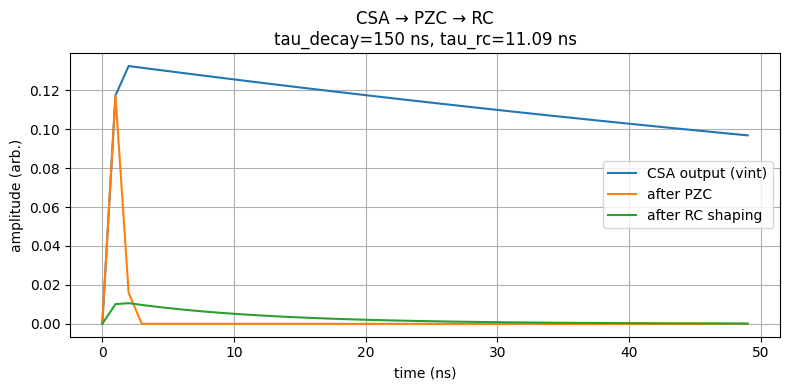

In [47]:
res = demo_frontend_chain(
    dt=1e-9,
    pulse_width=15e-9,
    tau_decay=150e-9,
)


In [48]:
def demo_frontend_chain(dt=1e-9, tau_decay=150e-9, pulse_width=15e-9, n=2000):
    # 1) 自动求 tau_rc
    tau_rc = tune_tau_rc_for_fwhm_pz_rc(
        dt,
        target_fwhm=pulse_width,
        tau_decay=tau_decay
    )

    # 2) 单事件：Q/Cf = 1
    t = np.arange(n) * dt
    event_times = np.array([0.0])
    V_pulse = np.array([1.0])

    Vint = integrate_with_decay(
        event_times, V_pulse, t, dt, tau_decay=tau_decay
    )

    # 3) PZC
    v_pz = pzc_from_vint(Vint, dt, tau_decay)

    # 4) RC shaping
    y = rc_filter(v_pz, dt, tau_rc)

    # 5) k_shaper
    k_shaper = np.max(y)

    return t, Vint, v_pz, y, tau_rc, k_shaper




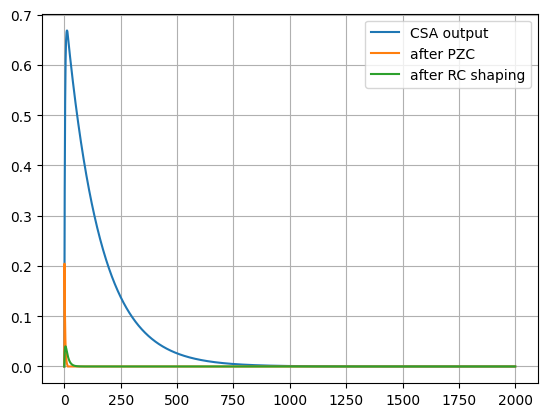

In [49]:
t, Vint, v_pz, y, tau_rc, k_shaper = demo_frontend_chain()

plt.plot(t*1e9, Vint, label="CSA output")
plt.plot(t*1e9, v_pz, label="after PZC")
plt.plot(t*1e9, y, label="after RC shaping")
plt.legend(); plt.grid()
